## GPU Computing — Best Practices

### ****Exercise 1:** Matmul Kernel Progression**

****Goal:** Run three matmul kernels and see the optimization ladder.**

1. **Run `matmul_benchmark.py` (on Moodle) — it times kernels 1, 2, and 3 plus `a @ b`**

Note that the filename has changed to `e1_matmul_benchmark.py`

In [1]:
%run -i e1_matmul_benchmark.py

Device: gfx1035
N=1024  TILE_SIZE=16  runs=3



/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(


matmul1 (naive):        99.4 ms
matmul2 (row-based):    130.5 ms
matmul3 (tiled):        7.3 ms
numpy matmul:           7.8 ms

Saved: matmul_benchmark.png


2. **Look at the bar chart saved to `matmul_benchmark.png`**

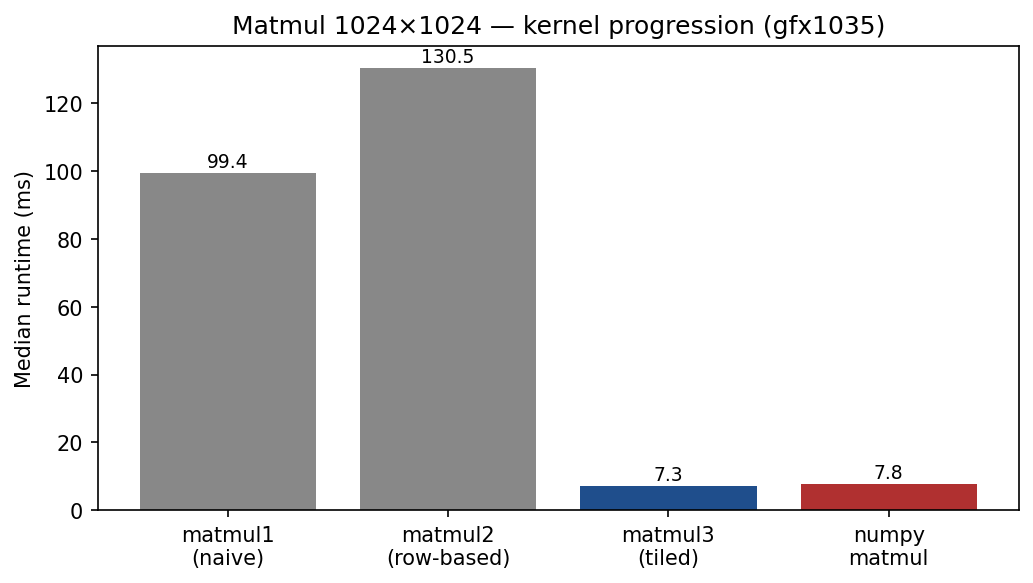

In [2]:
from IPython.display import display, Image

display(Image("matmul_benchmark.png"))

3. **Understand why each step is faster (see next slide for a diagram):**

- **Kernel 1 → kernel 2: private accumulator — row of A stays in registers, fewer global reads**

- **Kernel 2 → kernel 3: tiled local memory — each A/B element loaded from global memory once, reused `TILE_SIZE` times**

The titled allows for more optimised memory access patterns (i.e using the registers), making it a tad bit faster than numpy on the cpu.

**Questions to discuss:**

- **What is the speedup from kernel 1 to kernel 2? From kernel 2 to kernel 3?**

$$ S_{1 \rightarrow 2} = \frac{99.4 \space \text{ms}}{130.5 \space \text{ms}} = 0.76 \times $$

$$ S_{2 \rightarrow 3} = \frac{130.5 \space \text{ms}}{7.3 \space \text{ms}} = 17.88 \times $$

- **How does the tiled kernel (3) compare to `a @ b`?**

$$ S_{\text{a@b} \rightarrow 3} = \frac{7.8 \space \text{ms}}{7.3 \space \text{ms}} = 1.07 \times $$

Running the matrix multiplication on the GPU is slightly faster using the tiled kernel.

- **Why does NumPy win or lose?**

NumPy losses for me, but it was a close call. With mamba, NumPy is compiled against acceleration libs such as OpenBLAS likely using hardware vector acceleration (such as avx512), which my CPU does not support. If it did I suspect that NumPy would have been faster.

****Done?** Discuss the bar chart with a neighbour → move on to E2**

### ****Exercise 2:** Tile Size Sweep**

****Goal:** Vary `TILE_SIZE` and observe the effect on kernel 3 runtime.**

**Change the constant at the top of `matmul_benchmark.py`:**
```python
TILE_SIZE = 8 # try also 16 and 32
```

In [3]:
!sed --in-place 's/^TILE_SIZE = .*/TILE_SIZE = 8/' e1_matmul_benchmark.py

In [4]:
!grep TILE_SIZE e1_matmul_benchmark.py

  matmul3  -- tiled: blocks loaded into local memory; TILE_SIZE x TILE_SIZE reuse
TILE_SIZE = 8
        f"-D DIM={N} -D TILE_SIZE={TILE_SIZE}"
    print(f"N={N}  TILE_SIZE={TILE_SIZE}  runs={RUNS}\n")
    t = timed(queue, lambda: k3(queue, (N, N), (TILE_SIZE, TILE_SIZE), a_dev, b_dev, r_dev))


**Check the work-group size limit before running:**

In [5]:
import pyopencl as cl

ctx = cl.create_some_context(interactive=False)
dev = ctx.devices[0]
print(f"max_work_group_size: {dev.max_work_group_size}") 
# TILE_SIZE^2 must not exceed this value

max_work_group_size: 256


**Local memory budget (check if device is limited):**

In [6]:
print(f"local_mem_size: {dev.local_mem_size // 1024} KB")
# Each tile pair costs 2 * TILE_SIZE^2 * 4 bytes

local_mem_size: 64 KB


****Before sweeping:** run the introspection script from L10 and note for your device:**

*Note:* I use clinfo in L10.

- **`max_work_group_size` — `TILE SIZE`<sup>2</sup> must not exceed this**

In [7]:
!clinfo --device 0:0 | grep -i "Max work group size"

  Max work group size                             256
  Max work group size (AMD)                       1024


- **`local_mem_size` — each tile pair uses $2 \times T^2 \times 4$ bytes**

In [8]:
!clinfo --device 0:0 | grep -i "Local memory size"

  Local memory size                               65536 (64KiB)
  Local memory size per CU (AMD)                  65536 (64KiB)


1. **Edit `e1_matmul_benchmark.py`: change `TILE_SIZE` to 2, 4, 8, 16, 32 (or as high as your device allows)**

*Note:* I made a copy for it instead.

In [9]:
from pathlib import Path
import numpy as np
import pyopencl as cl
from e1_matmul_benchmark import timed

N          = 1024      # matrix dimension (N x N)
RUNS       = 3         # median of this many kernel launches

HERE = Path.cwd()


def load_kernels(ctx, tile_size):
    # Allow to compile with other tile sizes
    sources = [
        (HERE / "matmul_kernel1.cl").read_text(),
        (HERE / "matmul_kernel2.cl").read_text(),
        (HERE / "matmul_kernel3.cl").read_text(),
    ]
    return cl.Program(ctx, "\n".join(sources)).build(
        f"-D DIM={N} -D TILE_SIZE={tile_size}"
    )

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
dev   = ctx.devices[0]
print(f"Device: {dev.name}")

rng    = np.random.default_rng(42)
a_host = rng.random((N, N), dtype=np.float32)
b_host = rng.random((N, N), dtype=np.float32)
r_host = np.empty((N, N), dtype=np.float32)
expected = a_host @ b_host

results = {
    "kernel": [],
    "tile": [],
    "time": []
}

tile_size = 2
while True:
    try:
        print(f"\n===== TILE_SIZE = {tile_size} =====")

        prog = load_kernels(ctx, tile_size)

        mf    = cl.mem_flags
        a_dev = cl.Buffer(ctx, mf.READ_ONLY  | mf.COPY_HOST_PTR, hostbuf=a_host)
        b_dev = cl.Buffer(ctx, mf.READ_ONLY  | mf.COPY_HOST_PTR, hostbuf=b_host)
        r_dev = cl.Buffer(ctx, mf.WRITE_ONLY, r_host.nbytes)

        k1 = cl.Kernel(prog, "matmul")
        k2 = cl.Kernel(prog, "matmul2")
        k3 = cl.Kernel(prog, "matmul3")

        # --- Kernel 1: naive ---
        t = timed(queue, lambda: k1(queue, (N, N), None, a_dev, b_dev, r_dev))
        cl.enqueue_copy(queue, r_host, r_dev); queue.finish()
        assert np.allclose(r_host, expected, atol=1e-3), "matmul1 incorrect"
        print(f"matmul1 (naive):     {t*1000:.1f} ms")
        results["kernel"].append("naive")
        results["tile"].append(tile_size)
        results["time"].append(t)

        # --- Kernel 2: row-based ---
        t = timed(queue, lambda: k2(queue, (N,), (min(64, dev.max_work_group_size),), a_dev, b_dev, r_dev))
        cl.enqueue_copy(queue, r_host, r_dev); queue.finish()
        assert np.allclose(r_host, expected, atol=1e-3), "matmul2 incorrect"
        print(f"matmul2 (row):       {t*1000:.1f} ms")
        results["kernel"].append("row-based")
        results["tile"].append(tile_size)
        results["time"].append(t)

        # --- Kernel 3: tiled local memory ---
        t = timed(queue, lambda: k3(queue, (N, N), (tile_size, tile_size), a_dev, b_dev, r_dev))
        cl.enqueue_copy(queue, r_host, r_dev); queue.finish()
        assert np.allclose(r_host, expected, atol=1e-3), "matmul3 incorrect"
        print(f"matmul3 (tiled):     {t*1000:.1f} ms")
        results["kernel"].append("tiled-local-memory")
        results["tile"].append(tile_size)
        results["time"].append(t)

        tile_size *= 2

    except cl.Error as e:
        print(e)
        break

Device: gfx1035

===== TILE_SIZE = 2 =====


/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(


matmul1 (naive):     98.9 ms
matmul2 (row):       136.2 ms
matmul3 (tiled):     129.1 ms

===== TILE_SIZE = 4 =====
matmul1 (naive):     107.6 ms
matmul2 (row):       153.7 ms
matmul3 (tiled):     27.6 ms

===== TILE_SIZE = 8 =====
matmul1 (naive):     99.0 ms
matmul2 (row):       129.6 ms
matmul3 (tiled):     10.6 ms

===== TILE_SIZE = 16 =====
matmul1 (naive):     101.2 ms
matmul2 (row):       137.6 ms
matmul3 (tiled):     7.7 ms

===== TILE_SIZE = 32 =====
matmul1 (naive):     97.1 ms
matmul2 (row):       130.1 ms
clEnqueueNDRangeKernel failed: INVALID_WORK_GROUP_SIZE


2. **Record the kernel 3 runtime each time**

Done! Please see the code above. I reuse the form from `e1_matmul_benchmark.py`

3. **Plot runtime vs tile size (or note the three numbers)**

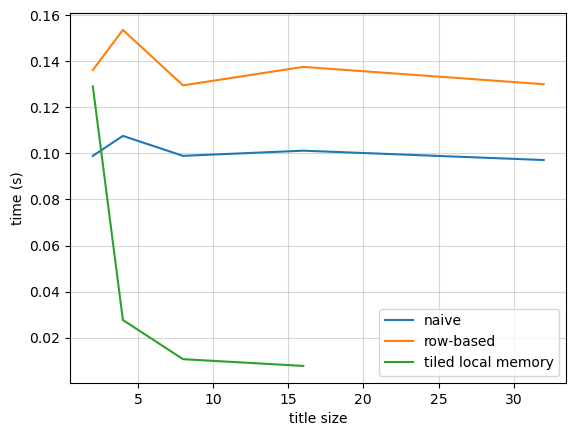

In [10]:
# AI assisted

import matplotlib.pyplot as plt

kernel = np.array(results["kernel"])
tile   = np.array(results["tile"])
time   = np.array(results["time"])

# --- naive ---
m = kernel == "naive"
x = tile[m]
y = time[m]
plt.plot(x, y, label="naive")

# --- row-based ---
m = kernel == "row-based"
x = tile[m]
y = time[m]
i = np.argsort(x)
plt.plot(x, y, label="row-based")

# --- tiled ---
m = kernel == "tiled-local-memory"
x = tile[m]
y = time[m]
i = np.argsort(x)
plt.plot(x, y, label="tiled local memory")

plt.xlabel("title size")
plt.ylabel("time (s)")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

**Questions to discuss:**

- **Which tile size gives the best runtime?**

The one using titled local memory of 16 tiles. $7.7$ ms.

- **Can you explain the optimum (or the ceiling) in terms of your device’s `max_work_group_size` or `local_mem_size` (see `introspection.py` script from L10)?**

In [11]:
!python introspection.py


OpenCL Platforms and Devices
Platform - Name:  AMD Accelerated Parallel Processing
Platform - Vendor:  Advanced Micro Devices, Inc.
Platform - Version:  OpenCL 2.1 AMD-APP (3581.0)
Platform - Profile:  FULL_PROFILE
    --------------------------------------------------------
    Device - Name:  gfx1035
    Device - Type:  ALL | GPU
    Device - Max Clock Speed:  2200 Mhz
    Device - Compute Units:  6
    Device - Local Memory:  64 KB
    Device - Constant Memory:  13426882 KB
    Device - Global Memory: 15 GB
    Device - Max Buffer/Image Size: 13112 MB
    Device - Max Work Group Size: 256
Platform - Name:  Intel(R) OpenCL
Platform - Vendor:  Intel(R) Corporation
Platform - Version:  OpenCL 3.0 LINUX
Platform - Profile:  FULL_PROFILE
    --------------------------------------------------------
    Device - Name:  AMD Ryzen 7 PRO 6850U with Radeon Graphics     
    Device - Type:  ALL | CPU
    Device - Max Clock Speed:  0 Mhz
    Device - Compute Units:  16
    Device - Local Memory

For a tile size of $32$, we exceed my GPU device. ($32^2 = 1024$, which is way larger than $256$. It cannot fit.)

Fro the exception above, we do no hit any local memory size limits. From the OpenCL kernel `matmul_kernel3.cl` we can see that we need $\text{TILE\_SIZE}^2$ floats of local memory. For tile size of $32$ this would use $4 \space \text{Bytes} \times 32^2 = 8096 \space \text{Bytes}$. Thus we (would) only use: $\frac{8 \space \text{KB}}{64 \space \text{KB}} = 0.13\%$ of local memory.

- **Does a larger tile always help? Why or why not?**

It depends on the workload and hardware. From the figure above, it looks like a larger tile size does not help. Using local memory does though.

****Done?** Discuss with a neighbour → move on to E3**

### ****Exercise 3:** Parallel Reduction**

**Goal: Implement `sum(x)` and `sum(x^2)` for a 1M-element float32 array in OpenCL with both naive and tree reduction (explained below) and compare to numpy (CPU).**

> **Hint: Use 1 kernel template, substitute operation via an f-string: `LOAD = "v"` or `LOAD = "v*v"`.**

**Naive (start here):**

```c
__kernel void reduce_naive(
    __global const float* data,
    __global float* partial, int n)
{
    __local float scratch[WG];
    int gid = get_global_id(0);
    int lid = get_local_id(0);
    float v = (gid < n) ? data[gid] : 0.f;
    scratch[lid] = {LOAD};
    barrier(CLK_LOCAL_MEM_FENCE);
    if (lid == 0) {
        float s = 0.f;
        for (int i = 0; i < WG; ++i)
            s += scratch[i];
        partial[get_group_id(0)] = s;
    }
}
```

- **Each work-item loads one element into `__local float scratch[WG]`**

- **Work-item 0 serially sums the entire scratch array and writes one partial result to global memory**

- **The host reads one partial result per work-group and reduces with `np.sum`**

**Tree reduction:**

```c
__kernel void reduce_tree(
    __global const float* data,
    __global float* partial, int n)
{
    __local float scratch[WG];
    int gid = get_global_id(0);
    int lid = get_local_id(0);
    float v = (gid < n) ? data[gid] : 0.f;
    scratch[lid] = {LOAD};
    barrier(CLK_LOCAL_MEM_FENCE);
    for (int off = WG/2; off > 0; off >>= 1) {
        if (lid < off)
            scratch[lid] += scratch[lid + off];
        barrier(CLK_LOCAL_MEM_FENCE);
    }
    if (lid == 0)
        partial[get_group_id(0)] = scratch[0];
}
```

- **Same load into scratch; reduce with a binary tree and `barrier(CLK LOCAL MEM FENCE)`**

- **Work-item 0 writes the group result; host reduces with `np.sum` as before**

**Questions:**

- **Does GPU `sum(x)` beat `np.sum`? How does tree compare to naive?**

- **Does GPU `sum(x^2)` beat `np.sum(data**2)`? Why the difference?**

****Done?** Discuss with a neighbour**